In [6]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

data_path = Path("powerConsumption.csv")
df = pd.read_csv(data_path, parse_dates=["DateTime"])
df = df.sort_values("DateTime").set_index("DateTime")
missing_counts = df.isna().sum()
if missing_counts.any():
    print("Missing values per collumn:\n", missing_counts)
print("Original sampling:", df.shape)
resample_rule = "60min"
df_resampled = df.resample(resample_rule).mean()
print("Size after resampling:", df_resampled.shape)
df_resampled.head()

split_idx = int(len(df_resampled) * 0.75)
train_df = df_resampled.iloc[:split_idx]
test_df = df_resampled.iloc[split_idx:]

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)
print("Train range", train_df.index.min(), "-", train_df.index.max())
print("Test range", test_df.index.min(), "-", test_df.index.max())

Original sampling: (52416, 8)
Size after resampling: (8736, 8)
Train shape: (6552, 8) Test shape: (2184, 8)
Train range 2017-01-01 00:00:00 - 2017-09-30 23:00:00
Test range 2017-10-01 00:00:00 - 2017-12-30 23:00:00


In [7]:
lags = [1, 2, 3, 24]  # 1, 2, 3, 24 hours
lagged_df = df_resampled.copy()

for lag in lags:
    for col in df_resampled.columns:
        lagged_df[f'{col}_lag_{lag}'] = df_resampled[col].shift(lag)

lagged_df = lagged_df.dropna()

print(lagged_df.head())
print("Shape after adding lags and removing NaN:", lagged_df.shape)

                     Temperature   Humidity  Wind Speed  \
DateTime                                                  
2017-01-02 00:00:00    10.666667  78.033333    0.076667   
2017-01-02 01:00:00    10.703333  78.916667    0.076167   
2017-01-02 02:00:00    11.031667  76.750000    0.077833   
2017-01-02 03:00:00    10.568333  79.266667    0.077500   
2017-01-02 04:00:00    10.253333  81.933333    0.076167   

                     general diffuse flows  diffuse flows  \
DateTime                                                    
2017-01-02 00:00:00               0.065833       0.140500   
2017-01-02 01:00:00               0.071333       0.138667   
2017-01-02 02:00:00               0.068500       0.147667   
2017-01-02 03:00:00               0.069000       0.143500   
2017-01-02 04:00:00               0.076333       0.139667   

                     Zone 1 Power Consumption  Zone 2  Power Consumption  \
DateTime                                                                   
2017-0

In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

target_col = 'Zone 1 Power Consumption'
X = lagged_df.drop(columns=[target_col])
y = lagged_df[target_col]

split_idx_lagged = int(len(lagged_df) * 0.75)
X_train, X_test = X.iloc[:split_idx_lagged], X.iloc[split_idx_lagged:]
y_train, y_test = y.iloc[:split_idx_lagged], y.iloc[split_idx_lagged:]

model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mape = mean_absolute_percentage_error(y_test, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")
print(f"\nFirst 10 predictions:")
print(f"Prediction: {y_pred[:10]}")
print(f"Reality: {y_test.values[:10]}")
print(f"Difference in %: {((y_pred[:10] - y_test.values[:10]) / y_test.values[:10]) * 100}")

MAPE: 4.31%
RMSE: 1608.22

First 10 predictions:
Prediction: [22845.736 22748.912 25038.244 28019.262 31058.79  32910.965 34049.383
 34129.566 33128.07  31817.996]
Reality: [22125.164115   23137.680525   25755.09846833 29119.29978167
 32066.52078667 33733.391685   34217.592995   34208.14004333
 33777.50547333 32273.43544833]
Difference in %: [ 3.2567994  -1.68023936 -2.7833492  -3.77769408 -3.14262882 -2.43802002
 -0.49158976 -0.22969281 -1.92268538 -1.41118957]


In [9]:
# Baseline for comparison

# Naive Baseline last known value (lag_1)
y_pred_naive = X_test['Zone 1 Power Consumption_lag_1'].values

mape_naive = mean_absolute_percentage_error(y_test, y_pred_naive) * 100
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))

print("BASELINE: Naive (last known value)")
print(f"MAPE: {mape_naive:.2f}%")
print(f"RMSE: {rmse_naive:.2f}")

# Moving average baseline
y_pred_ma = X_test[[f'Zone 1 Power Consumption_lag_{i}' for i in [1,2,3,24]]].mean(axis=1).values

mape_ma = mean_absolute_percentage_error(y_test, y_pred_ma) * 100
rmse_ma = np.sqrt(mean_squared_error(y_test, y_pred_ma))

print("\nBASELINE: Moving average of lags [1,2,3,24]")
print(f"MAPE: {mape_ma:.2f}%")
print(f"RMSE: {rmse_ma:.2f}")

print("\nComparison with XGBoost (from previous cell)")
print(f"XGBoost MAPE: {mape:.2f}%  (baseline naive: {mape_naive:.2f}%)")
print(f"XGBoost RMSE: {rmse:.2f}  (baseline naive: {rmse_naive:.2f})")
print(f"\nImprovement over baseline: {((mape_naive - mape) / mape_naive * 100):.1f}% (MAPE)")

BASELINE: Naive (last known value)
MAPE: 6.05%
RMSE: 2474.40

BASELINE: Moving average of lags [1,2,3,24]
MAPE: 8.26%
RMSE: 3162.23

Comparison with XGBoost (from previous cell)
XGBoost MAPE: 4.31%  (baseline naive: 6.05%)
XGBoost RMSE: 1608.22  (baseline naive: 2474.40)

Improvement over baseline: 28.8% (MAPE)


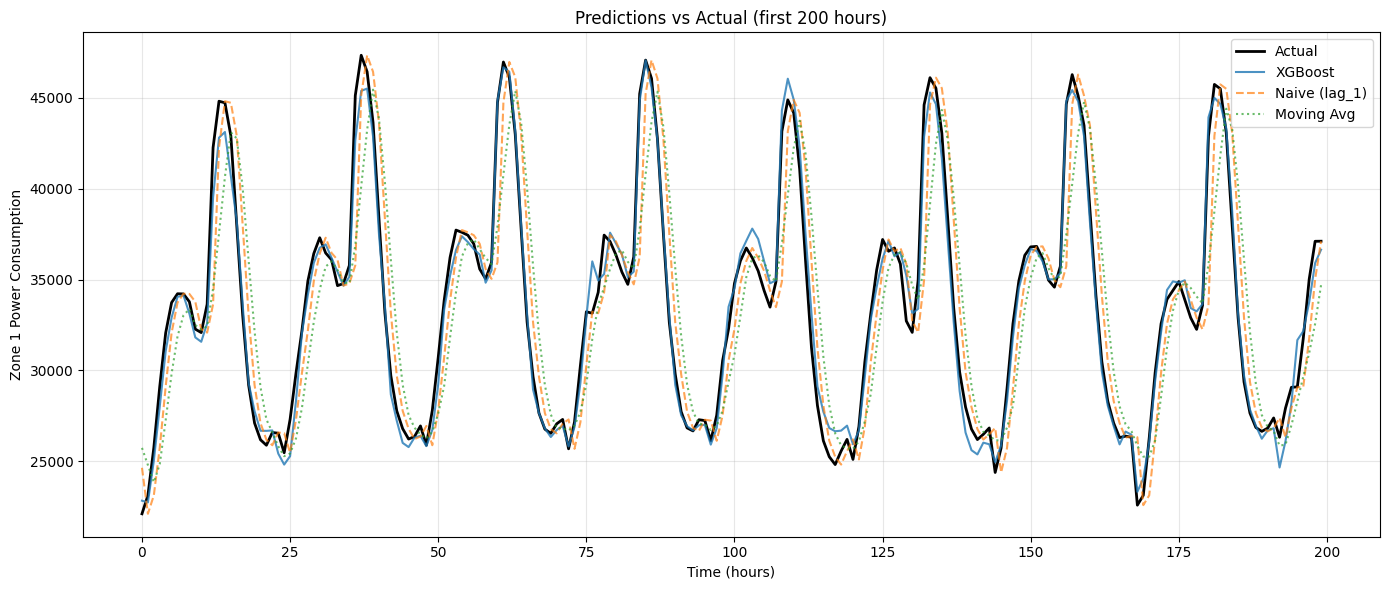

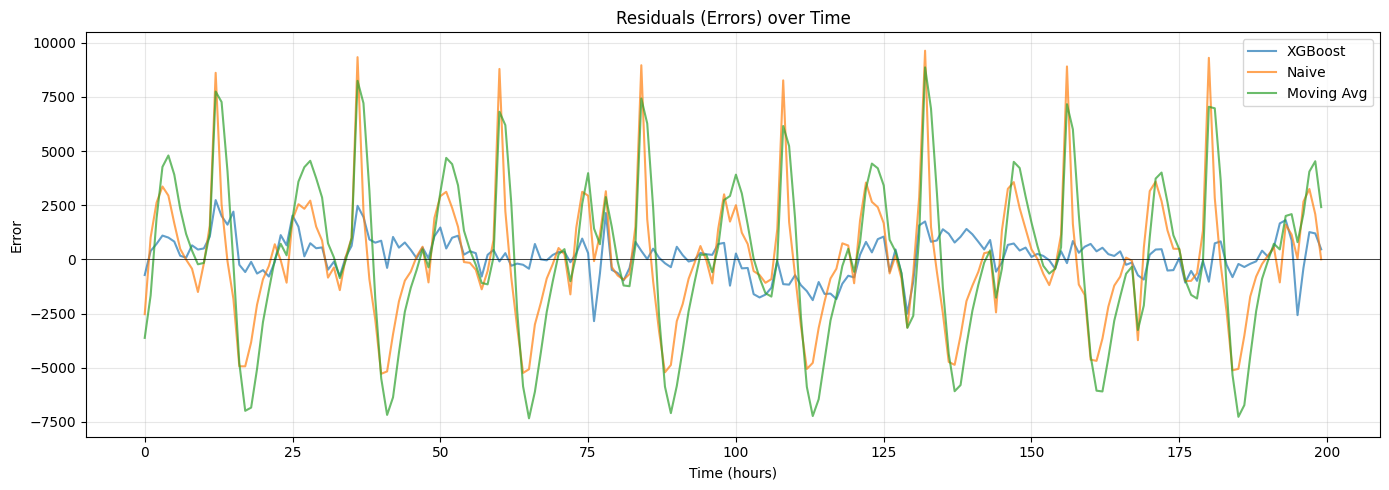

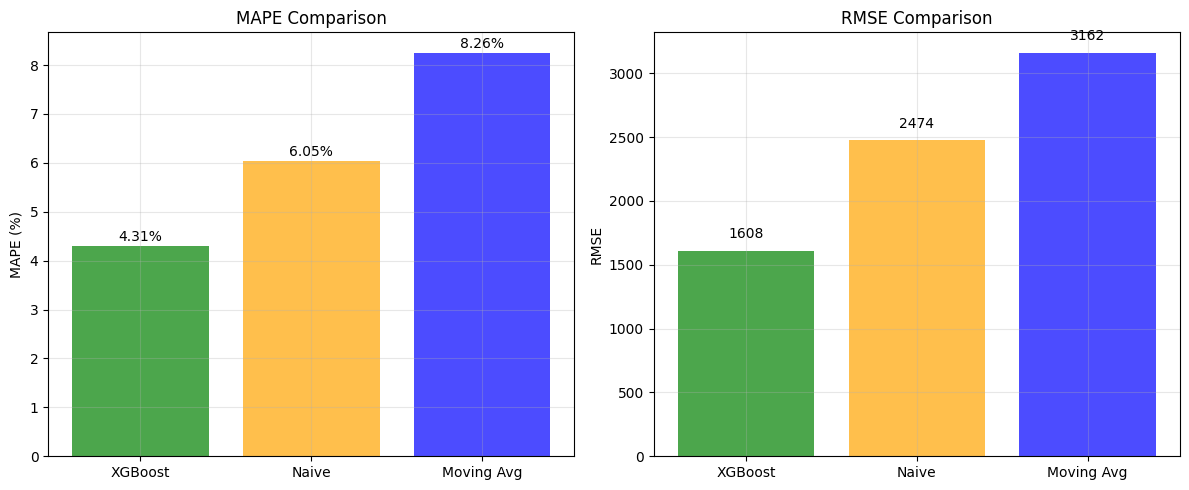

In [ ]:
import matplotlib.pyplot as plt

# first 200 hours
window = 200
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.values[:window], label='Actual', linewidth=2, color='black')
ax.plot(y_pred[:window], label='XGBoost', alpha=0.8)
ax.plot(y_pred_naive[:window], label='Naive (lag_1)', alpha=0.7, linestyle='--')
ax.plot(y_pred_ma[:window], label='Moving Avg', alpha=0.7, linestyle=':')
ax.set_title(f'Predictions vs Actual (first {window} hours)')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Zone 1 Power Consumption')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# residuals
fig, ax = plt.subplots(figsize=(14, 5))
residuals_xgb = y_test.values - y_pred
residuals_naive = y_test.values - y_pred_naive
residuals_ma = y_test.values - y_pred_ma
ax.plot(residuals_xgb[:window], label='XGBoost', alpha=0.7)
ax.plot(residuals_naive[:window], label='Naive', alpha=0.7)
ax.plot(residuals_ma[:window], label='Moving Avg', alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Residuals (Errors) over Time')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# metrics comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
models = ['XGBoost', 'Naive', 'Moving Avg']
mapes = [mape, mape_naive, mape_ma]
rmses = [rmse, rmse_naive, rmse_ma]
ax1.bar(models, mapes, color=['green', 'orange', 'blue'], alpha=0.7)
ax1.set_ylabel('MAPE (%)')
ax1.set_title('MAPE Comparison')
ax1.grid(True, alpha=0.3)
for i, v in enumerate(mapes):
    ax1.text(i, v + 0.1, f'{v:.2f}%', ha='center')
ax2.bar(models, rmses, color=['green', 'orange', 'blue'], alpha=0.7)
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE Comparison')
ax2.grid(True, alpha=0.3)
for i, v in enumerate(rmses):
    ax2.text(i, v + 100, f'{v:.0f}', ha='center')
plt.tight_layout()
plt.show()